# Ejercicio 1: Lectura e inspección básica de datos #




In [1]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 999.4/999.4 kB 36.4 MB/s eta 0:00:00


# ----------------------------------------
# 📦 Parámetros comunes de GAIA DR3
# ----------------------------------------

## ID único de cada estrella
## source_id

## Coordenadas ecuatoriales (grados)
## ra  -> ascensión recta
## dec -> declinación

## Paralaje (mas = milisegundos de arco)
## parallax  -> Se puede usar para estimar distancia: distancia_pc ≈ 1000 / parallax

## Movimiento propio (mas/año)
## pmra  -> movimiento en ascensión recta
## pmdec -> movimiento en declinación

## Magnitudes fotométricas
## phot_g_mean_mag  -> magnitud G
## phot_bp_mean_mag -> magnitud BP (azul)
## phot_rp_mean_mag -> magnitud RP (rojo)

## Color de la estrella (BP - RP)
## bp_rp

## Temperatura efectiva estimada (K)
## teff_gspphot

## Radio estimado de la estrella (en radios solares)
## radius_gspphot

## Luminosidad estimada (en L☉)
## lum_gspphot

## Velocidad radial (km/s)
## radial_velocity

## Calidad del ajuste astrométrico
## ruwe  -> se recomienda usar ruwe < 1.4 para obtener datos confiables

## Consulta SQL a GAIA con múltiples parámetros y filtros
query = '''
SELECT TOP 1000
source_id, ra, dec, parallax, phot_g_mean_mag, bp_rp,radial_velocity, teff_gspphot, radius_gspphot, ruwe
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 2 AND 10         -- Estrellas entre ~100 y ~500 pc
  AND phot_g_mean_mag < 17              -- Brillo moderado
  AND ruwe < 1.4                        -- Calidad del ajuste astrométrico
'''



In [59]:
from astroquery.gaia import Gaia
import pandas as pd


# pc = 1000/mas
# Consulta simple de 1000 estrellas brillantes y cercanas desde GAIA
query = '''
SELECT TOP 1000000
source_id, ra, dec,l,b, parallax, phot_g_mean_mag, bp_rp, radial_velocity, teff_gspphot, ruwe
FROM gaiadr3.gaia_source
WHERE parallax BETWEEN 1 AND 8000      -- Estrellas entre ~10 y ~1 pc
  AND phot_g_mean_mag < 21              -- Brillo moderado
  AND ruwe < 0.5                        -- Calidad del ajuste astrométrico
'''

# Ejecutar consulta
job = Gaia.launch_job_async(query)
results = job.get_results()

# Convertir a DataFrame de pandas y guardar como CSV
df = results.to_pandas()
#df.to_csv("estrellas.csv", index=False)
#print("Archivo 'estrellas.csv' generado correctamente.")


INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


**Preguntas:**
1. ¿Cuántas estrellas hay en el catálogo?
2. ¿Cuál es el rango de valores para la columna `parallax`?
3. ¿Qué representa la columna `bp_rp`?

In [62]:
df

,source_id,ra,dec,l,b,parallax,phot_g_mean_mag,bp_rp,radial_velocity,teff_gspphot,ruwe
0,4150476491615872128,269.033945,-12.972248,15.013370,6.020860,1.000000,15.659847,1.690042,NaN,5887.120605,0.938763
1,1834761959580470144,301.006777,25.404203,63.653139,-3.139949,1.000000,18.848160,2.477573,NaN,3776.784668,0.942617
2,1135105675321827712,121.088462,73.852198,140.886276,31.025676,1.000000,14.449145,0.874846,-10.887208,5562.435547,0.897268
3,4255368011073381248,284.227517,-4.339611,29.688602,-3.192483,1.000000,20.549252,2.167639,NaN,NaN,0.828898
4,5490804908398735616,109.084631,-54.542422,265.508200,-18.387136,1.000000,20.698193,1.833958,NaN,NaN,0.967872
...,...,...,...,...,...,...,...,...,...,...,...
2999995,5969018833572676480,250.451979,-40.952303,342.636895,3.518707,1.030354,18.751984,2.192396,NaN,3710.859131,0.963850
2999996,4099317005834177920,282.882556,-16.346332,18.312176,-7.393164,1.030354,15.809614,1.254223,NaN,5568.818359,0.967843
2999997,4534070771073394560,282.242543,23.739643,54.064673,11.089521,1.030354,19.368034,1.909985,NaN,NaN,0.983365
2999998,5936818055024208128,253.358183,-50.607338,336.565325,-4.258242,1.030354,20.418011,NaN,NaN,NaN,0.890757


## Ejercicio 2: Filtrado de datos

Seleccione estrellas dentro de un radio de 10 pc, utilizar estrellas con magnitudes menores a 15 en la banda g.

**Preguntas:**
1. ¿Cuántas estrellas cumplen esta condición?
2. ¿Qué puedes inferir respecto a su distancia y brillo?

In [63]:
# Filtrar estrellas con parallax < 5 y magnitud G < 15
cercanas_bril = df[(df["phot_g_mean_mag"] < 15) ]
cercanas_bril

,source_id,ra,dec,l,b,parallax,phot_g_mean_mag,bp_rp,radial_velocity,teff_gspphot,ruwe
2,1135105675321827712,121.088462,73.852198,140.886276,31.025676,1.000000,14.449145,0.874846,-10.887208,5562.435547,0.897268
24,6061501471020364160,194.082214,-55.931177,303.621892,6.934021,1.000000,14.819943,0.986103,NaN,5906.683594,0.978198
25,5679466397757261568,137.771379,-20.599190,248.917658,18.442978,1.000000,14.023001,1.010049,8.348023,5313.590332,0.948711
50,4264693828215152256,289.227426,1.324992,37.027386,-5.056664,1.000000,14.786727,1.242967,-32.453350,5603.376465,0.928248
51,6027866826228551168,252.275526,-31.453218,350.886115,8.531757,1.000000,14.373652,1.125094,-12.639354,6092.971191,0.905436
...,...,...,...,...,...,...,...,...,...,...,...
2999972,6342160713156366976,332.302596,-86.227767,305.762201,-29.965725,1.030354,14.873000,0.982555,NaN,5297.221680,0.973679
2999974,1850690726266515456,324.105617,31.856826,81.559278,-14.934383,1.030354,14.799306,0.939403,NaN,5689.143066,0.962317
2999984,187405301623533568,78.509213,37.870401,168.921372,-0.558992,1.030354,14.261110,1.025439,-20.299110,5796.895996,0.970762
2999987,1639832124365359616,234.452782,62.876472,97.505997,45.177295,1.030354,14.846954,0.861337,NaN,5658.841309,0.942821


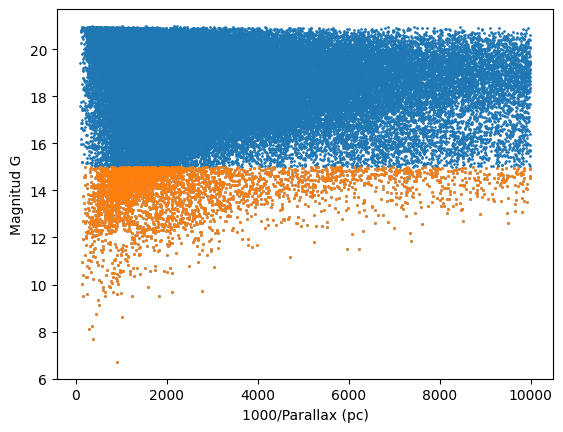

In [50]:
import matplotlib.pyplot as plt

plt.scatter(1000/df['parallax'], df['phot_g_mean_mag'], s=1)
plt.xlabel('1000/Parallax (pc)')
plt.ylabel('Magnitud G')
plt.scatter(1000/cercanas_bril['parallax'], cercanas_bril['phot_g_mean_mag'], s=1)
plt.show()

## Ejercicio 3: Estadísticas básicas y agrupamiento

Agrupe las estrellas en bins de paralaje.
**Preguntas:**
1. ¿Cómo varía el brillo promedio según el paralaje?
2. ¿Se observa alguna relación esperada?

In [51]:
# Crear bin de parallax
df["parallax_bin"] = pd.cut(df["parallax"], bins=1000)

# Calcular promedio de magnitud G por bin
grupo = df.groupby("parallax_bin")["phot_g_mean_mag"].mean()
grupo

<ipython-input-51-ebc343c7f1e8>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = df.groupby("parallax_bin")["phot_g_mean_mag"].mean()


,phot_g_mean_mag
parallax_bin,
"(0.0881, 0.219]",18.307077
"(0.219, 0.338]",18.413651
"(0.338, 0.457]",18.395903
"(0.457, 0.576]",18.424568
"(0.576, 0.695]",18.552147
...,...
"(11.412, 11.531]",NaN
"(11.531, 11.65]",NaN
"(11.65, 11.769]",NaN


(array([1.0000e+00, 2.0000e+00, 3.0000e+00, 6.0000e+00, 2.1000e+01,
        4.6000e+01, 7.0000e+01, 1.6800e+02, 4.1700e+02, 6.7300e+02,
        1.2030e+03, 2.0670e+03, 3.4660e+03, 5.2860e+03, 7.8820e+03,
        1.1071e+04, 1.5134e+04, 2.0731e+04, 2.0168e+04, 1.1585e+04]),
 array([ 6.71083021,  7.42481804,  8.13880539,  8.85279274,  9.56678104,
        10.28076839, 10.9947567 , 11.70874405, 12.4227314 , 13.13671875,
        13.8507061 , 14.5646944 , 15.27868271, 15.99267006, 16.70665741,
        17.42064476, 18.13463211, 18.84861946, 19.56260872, 20.27659607,
        20.99058342]),
 <BarContainer object of 20 artists>)

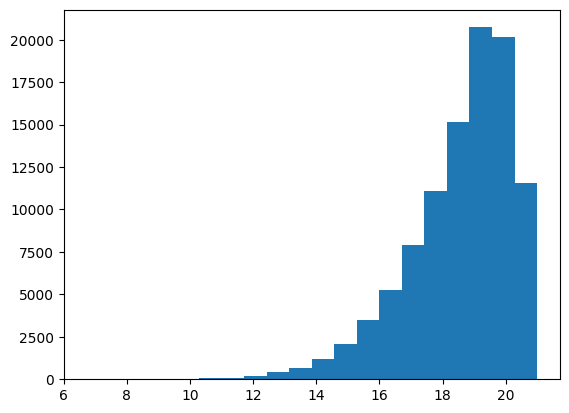

In [55]:
plt.hist(df["phot_g_mean_mag"],bins=20)

## Ejercicio 4: Coordenadas


 Compare las coordenadas AR y DEC a coordenadas Galácticas (l,b).
hint: use un grafico scatter \\

**Preguntas** \\
1) Que diferencia nota en la distribución de coordenadas? \\
2) Donde se encuentra el centro galactico en RA y DEC, y en l° y b°? \\
3) Que puede apreciar en la distribucion de la latitud b°? \\

In [57]:
import astropy.coordinates
from astropy.coordinates import SkyCoord
from astropy import units as u
import numpy as np

(array([  2306.,   6378.,  11230.,  19390.,  32652.,  56188., 107079.,
        169837., 378775., 835718., 694549., 332623., 145805.,  84244.,
         52465.,  32387.,  19111.,  10927.,   6072.,   2264.]),
 array([-8.97879165e+01, -8.08180149e+01, -7.18481132e+01, -6.28782116e+01,
        -5.39083099e+01, -4.49384083e+01, -3.59685066e+01, -2.69986050e+01,
        -1.80287033e+01, -9.05880165e+00, -8.89000038e-02,  8.88100165e+00,
         1.78509033e+01,  2.68208049e+01,  3.57907066e+01,  4.47606082e+01,
         5.37305099e+01,  6.27004115e+01,  7.16703132e+01,  8.06402148e+01,
         8.96101165e+01]),
 <BarContainer object of 20 artists>)

<Figure size 640x480 with 0 Axes>

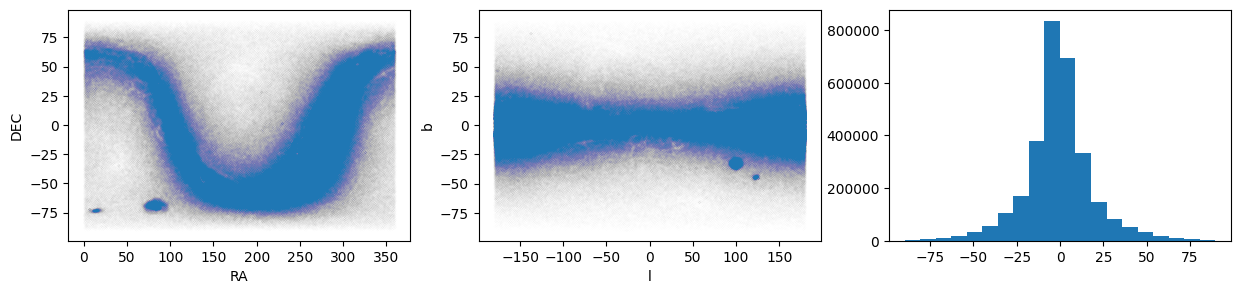

In [68]:
ra = df["ra"].values
dec = df["dec"].values
l = df["l"].values
b = df["b"].values
'''ra = cercanas_bril["ra"].values
dec = cercanas_bril["dec"].values
l = cercanas_bril["l"].values
b = cercanas_bril["b"].values'''

plt.figure()
f,ax=plt.subplots(1,3,figsize=[15,3])
ax[0].scatter(ra,dec,s=0.001,alpha=0.1)
ax[0].set(xlabel=('RA'),ylabel=('DEC'))
ax[1].scatter(l-180,b,s=0.001,alpha=0.1)
ax[1].set(xlabel=('l'),ylabel=('b'))
ax[2].hist(b,bins=20)

## Ejercicio 5: Visualización

Grafique un diagrama Color-Magbitud

**Preguntas:**
1. ¿Qué patrones observas?
2. ¿Dónde están las estrellas más brillantes y más azules?

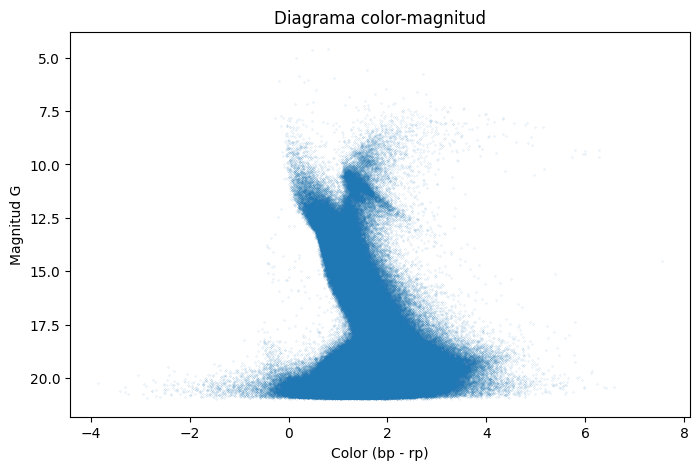

In [69]:
import matplotlib.pyplot as plt

# Crear diagrama color-magnitud
plt.figure(figsize=(8,5))
plt.scatter(df["bp_rp"], df["phot_g_mean_mag"], s=0.01, alpha=0.7)
plt.gca().invert_yaxis()
plt.xlabel("Color (bp - rp)")
plt.ylabel("Magnitud G")
plt.title("Diagrama color-magnitud")
plt.show()

#  Ejercicio Propuesto: Estrellas en la Vecindad Solar


### Parte 1: Histograma de magnitudes G

a) Traza un histograma de `phot_g_mean_mag` para las estrellas con `parallax > 5` (es decir, más cercanas a 200 pc).  
b) Describe cómo se distribuyen las magnitudes en este subconjunto.  
c) Propón un corte razonable de brillo para filtrar datos confiables (por ejemplo, G < 19).

---

### Parte 2: Estimación de distancia y análisis

a) Calcula la distancia estimada para cada estrella usando la fórmula:

\[
d (\text{pc}) = \frac{1000}{\text{parallax (mas)}}
\]

b) Construye un diagrama de dispersión:  
`distancia (pc)` vs `phot_g_mean_mag`.

c) Analiza el gráfico:  
- ¿Hasta qué distancia podemos confiar razonablemente en las magnitudes medidas?
- ¿Observas algún patrón relacionado con el brillo y la distancia?

In [82]:
# Filtrar estrellas cercanas (vecindad solar: parallax > 5 mas)
from astroquery.gaia import Gaia
import pandas as pd


# pc = 1000/mas
# Consulta simple de 1000 estrellas brillantes y cercanas desde GAIA
query = '''
SELECT
source_id, ra, dec,l,b, parallax, phot_g_mean_mag, bp_rp, radial_velocity, teff_gspphot, ruwe
FROM gaiadr3.gaia_source
WHERE parallax > 25                     -- Estrellas menores a 40 pc
  AND phot_g_mean_mag < 24              -- Brillo moderado
  AND ruwe < 1.0                        -- Calidad del ajuste astrométrico
'''

# Ejecutar consulta
job = Gaia.launch_job_async(query)
results = job.get_results()

# Convertir a DataFrame de pandas y guardar como CSV
vecindad = results.to_pandas()
vecindad
#df.to_csv("estrellas.csv", index=False)
#print("Archivo 'estrellas.csv' generado correctamente.")

INFO:astroquery:Query finished.


INFO: Query finished. [astroquery.utils.tap.core]


,source_id,ra,dec,l,b,parallax,phot_g_mean_mag,bp_rp,radial_velocity,teff_gspphot,ruwe
0,5226806600296754816,172.749550,-73.753063,297.292981,-11.768359,25.001629,16.546331,4.316390,NaN,NaN,0.927036
1,4539227892919675648,281.889821,28.347791,58.223511,13.283321,25.001837,18.439491,1.201639,NaN,NaN,0.937113
2,2281947396024587392,351.043924,78.072147,118.349378,15.984001,25.005760,15.864633,3.426208,NaN,2963.868896,0.981858
3,4519326874210461440,283.692115,21.669570,52.745307,8.995357,25.008620,17.342505,4.253937,NaN,NaN,0.963187
4,1847055603385721984,322.148008,26.359670,76.247776,-17.608293,25.009083,16.573851,3.672917,NaN,NaN,0.969738
...,...,...,...,...,...,...,...,...,...,...,...
3270,6553614253923452800,346.503917,-35.847164,5.097226,-65.987693,304.135369,6.522032,2.098285,8.306988,3376.084473,0.932005
3271,4075141768785646848,282.458789,-23.837097,11.307625,-10.287476,336.026602,9.126414,2.834036,-11.116440,3117.375977,0.988012
3272,762815470562110464,165.830960,35.948653,185.169510,65.433988,392.752945,6.551172,2.215609,-85.110641,3511.044922,0.963849
3273,3864972938605115520,164.103190,7.002727,244.051151,56.098853,415.179416,11.038391,4.184836,NaN,NaN,0.835335


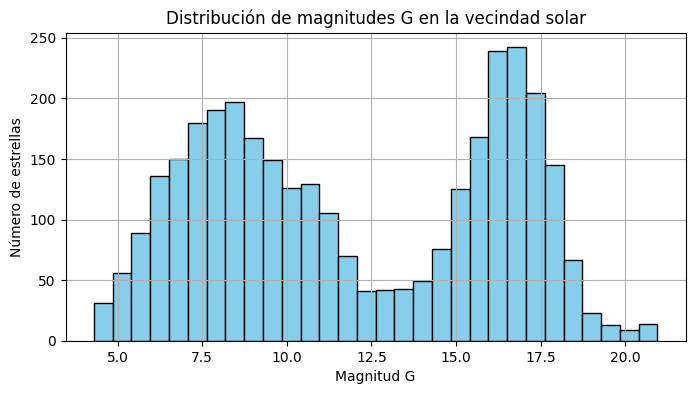

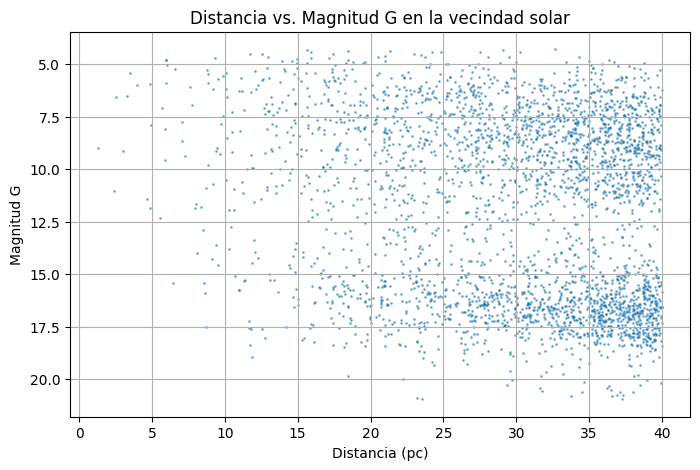

In [83]:
# Parte 1: Histograma de magnitudes G
plt.figure(figsize=(8,4))
plt.hist(vecindad["phot_g_mean_mag"], bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Magnitud G")
plt.ylabel("Número de estrellas")
plt.title("Distribución de magnitudes G en la vecindad solar")
plt.grid(True)
plt.show()

# Parte 2: Calcular distancia
vecindad = vecindad[vecindad["parallax"] > 0]  # evitar divisiones por cero
vecindad["dist_pc"] = 1000 / vecindad["parallax"]

# Diagrama distancia vs magnitud G
plt.figure(figsize=(8,5))
plt.scatter(vecindad["dist_pc"], vecindad["phot_g_mean_mag"], s=1, alpha=0.5)
plt.xlabel("Distancia (pc)")
plt.ylabel("Magnitud G")
plt.title("Distancia vs. Magnitud G en la vecindad solar")
plt.grid(True)
plt.gca().invert_yaxis()
plt.show()